In [16]:
import pandas as pd 
import numpy as np 
import json
import matplotlib.pyplot as plt

In [2]:
# Importar datos 
df_clientes_regulados = pd.read_csv("../data/raw/se_facturacion_clientes_regulados(in).csv", delimiter=";", encoding="utf-8-sig")
df_clientes_libres = pd.read_csv("../data/raw/se_venta_energia_clientes_libres(in).csv", delimiter=";", decimal=",", thousands=".")

In [3]:
# Función para reparar la doble codificación
def reparar_mojibake(texto):
    if isinstance(texto, str):
        try:
            # Ingeniería inversa: convertimos a bytes crudos cp1252 y decodificamos en utf-8
            return texto.encode('cp1252').decode('utf-8')
        except (UnicodeEncodeError, UnicodeDecodeError):
            # Si falla (ej. si la palabra ya estaba bien escrita), la dejamos intacta
            return texto
    return texto

# 3. Aplicar la función a las columnas de texto (ej. "region")
# Reemplaza 'nombre_region' por el nombre real de tu columna
df_clientes_regulados['region'] = df_clientes_regulados['region'].apply(reparar_mojibake)
df_clientes_regulados['comuna'] = df_clientes_regulados['comuna'].apply(reparar_mojibake)

# Comprobación
print(df_clientes_regulados['region'].unique())
print(df_clientes_regulados['comuna'].unique())

<ArrowStringArray>
['Región del Libertador Gral. Bernardo O’Higgins',
                              'Región del Biobío',
                               'Región del Maule',
                           'Región de Valparaíso',
               'Región Metropolitana de Santiago',
                         'Región de La Araucanía',
                            'Región de Los Lagos',
                              'Región de Atacama',
  'Región Aisén del Gral.Carlos Ibáñez del Campo',
                             'Región de Coquimbo',
                          'Región de Antofagasta',
                   'Región de Arica y Parinacota',
                             'Región de Tarapacá',
                                'Región de Ñuble',
                             'Región de Los Ríos',
 'Región de Magallanes y de la Antártica Chilena']
Length: 16, dtype: str
<ArrowStringArray>
[      'Las Cabras',      'La Estrella',         'Litueche',
          'Doñihue',         'Graneros',         'Coltauco',
 

In [4]:
# Limpieza exhaustiva de la columna RetiroEnergiaMWh
df_clientes_libres['RetiroEnergiaMWh'] = (
    df_clientes_libres['RetiroEnergiaMWh']
    .astype(str)                          # Asegurar que todo sea string
    .str.strip()                          # Eliminar espacios fantasma a los lados
    .str.replace('.', '', regex=False)    # Eliminar separadores de miles si los hay
    .str.replace(',', '.', regex=False)   # Cambiar coma decimal por punto de Python
)

# 3. Forzar a numérico. 
# errors='coerce' transformará cualquier basura ("-", "ND", etc.) en NaN (nulo)
df_clientes_libres['RetiroEnergiaMWh'] = pd.to_numeric(
    df_clientes_libres['RetiroEnergiaMWh'], 
    errors='coerce'
)

# Comprobación de que ahora sí es float
print(df_clientes_libres['RetiroEnergiaMWh'].dtype)

float64


In [5]:
# Identificación de regiones y comunas en cada fuente
regiones_regulados = df_clientes_regulados["region"].unique().tolist()
comunas_regulados = df_clientes_regulados["comuna"].unique().tolist()

regiones_libres = df_clientes_libres["Region"].unique().tolist()
comunas_libres = df_clientes_libres["Comuna"].unique().tolist()

print(10 * "-" + "Regiones" + 10 * "-")
print(f"Base de clientes regulados: {len(regiones_regulados)}")
print(regiones_regulados)
print(f"Base de clientes libres: {len(regiones_libres)}")
print(regiones_libres)

print(10 * "-" + "Comunas" + 10 * "-")
print(f"Base de clientes regulados: {len(comunas_regulados)}")
print(comunas_regulados)
print(f"Base de clientes libres: {len(comunas_libres)}")
print(comunas_libres)

----------Regiones----------
Base de clientes regulados: 16
['Región del Libertador Gral. Bernardo O’Higgins', 'Región del Biobío', 'Región del Maule', 'Región de Valparaíso', 'Región Metropolitana de Santiago', 'Región de La Araucanía', 'Región de Los Lagos', 'Región de Atacama', 'Región Aisén del Gral.Carlos Ibáñez del Campo', 'Región de Coquimbo', 'Región de Antofagasta', 'Región de Arica y Parinacota', 'Región de Tarapacá', 'Región de Ñuble', 'Región de Los Ríos', 'Región de Magallanes y de la Antártica Chilena']
Base de clientes libres: 29
['región del biobío', 'región de atacama', 'región del libertador gral. bernardo o’higgins', 'región de valparaíso', 'región de arica y parinacota', 'región de tarapacá', 'región del maule', 'región metropolitana de santiago', 'región de coquimbo', 'región de antofagasta', 'región de los ríos', 'región de la araucanía', 's/i', 'región de los lagos', 'región de ñuble', 'Región Metropolitana de Santiago', 'Región de La Araucanía', 'Región del Maul

In [10]:
# Diccionario de regiones 
mapa_regiones = {
    "TARAPACÁ": "TA", 
    "ANTOFAGASTA": "AN", 
    "ATACAMA": "AT", 
    "COQUIMBO": "CO", 
    "VALPARAÍSO": "VS", 
    "LIBERTADOR GENERAL BERNARDO O'HIGGINS": "LI", 
    "MAULE": "ML", 
    "BIOBÍO": "BI", 
    "LA ARAUCANÍA": "AR", 
    "LOS LAGOS": "LL", 
    "AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO": "AI", 
    "MAGALLANES Y DE LA ANTÁRTICA CHILENA": "MA", 
    "METROPOLITANA DE SANTIAGO": "RM", 
    "LOS RÍOS": "LR", 
    "ARICA Y PARINACOTA": "AP", 
    "ÑUBLE": "NB"
}

# Función para limpiar los nombres de las regiones
def limpiar_nombres(nombre):
    if pd.isna(nombre) or str(nombre).strip().lower() == 's/i':
        return np.nan
    
    # Mayúsculas y quitar espacios
    x = str(nombre).upper().strip()
    
    # Eliminar prefijos
    x = x.replace("REGIÓN DEL ", "").replace("REGIÓN DE ", "").replace("REGIÓN ", "")
    
    # Corregir abreviaturas y tildes específicas
    x = x.replace("GRAL.CARLOS", "GENERAL CARLOS")
    x = x.replace("GRAL. CARLOS", "GENERAL CARLOS")
    x = x.replace("GRAL. BERNARDO", "GENERAL BERNARDO")
    x = x.replace("O’HIGGINS", "O'HIGGINS") # Apóstrofe curvo a recto
    x = x.replace("AISÉN", "AYSÉN")
    
    return x

# Función para limpiar las comunas
def limpiar_comunas(nombre):
    if pd.isna(nombre) or str(nombre).strip().lower() == 's/i':
        return np.nan
    
    # Ñambotuicha (Mayúsculas sólidas para cruces seguros)
    x = str(nombre).upper().strip()
    
    # Ñamyatyrõ Mojibake (Arreglar el remanente de Los Ángeles/Álamos)
    x = x.replace("Ã\x81", "Á")
    
    return x

# ---------------------------------------------------------
# Aplicación a los DataFrames
# ---------------------------------------------------------
print("Aplicación a los DataFrames...")

# 1. Aplicar a df_clientes_regulados
# (Asumiendo que las columnas se llaman 'nombre_region' y 'comuna')
df_clientes_regulados['region_limpia'] = df_clientes_regulados['region'].apply(limpiar_nombres)
df_clientes_regulados['region_cod'] = df_clientes_regulados['region_limpia'].map(mapa_regiones)
df_clientes_regulados['comuna'] = df_clientes_regulados['comuna'].apply(limpiar_comunas)

# 2. Aplicar a df_clientes_libres
df_clientes_libres['region_limpia'] = df_clientes_libres['Region'].apply(limpiar_nombres)
df_clientes_libres['region_cod'] = df_clientes_libres['region_limpia'].map(mapa_regiones)
df_clientes_libres['Comuna'] = df_clientes_libres['Comuna'].apply(limpiar_comunas)

print("Campo de región y comunas actualizado")

# Puedes verificar los valores nulos para ver si alguna región no hizo "match" con el diccionario
print(df_clientes_regulados[df_clientes_regulados['region_cod'].isna()]['region'].unique())

# Limpiar la base
df_clientes_libres.dropna(subset=['RetiroEnergiaMWh', 'Comuna', 'Region', 'SectorEconomico', 'SubsectorEconomico'], inplace=True)

# Usamos una lista de posibles nombres sucios para que sea a prueba de errores
columnas_a_eliminar = ['nombre_region', 'region', 'Region']

df_clientes_regulados.drop(columns=[col for col in columnas_a_eliminar if col in df_clientes_regulados.columns], inplace=True)
df_clientes_libres.drop(columns=[col for col in columnas_a_eliminar if col in df_clientes_libres.columns], inplace=True)

# 4. Renombrar las nuevas columnas para dejarlas como definitivas
df_clientes_regulados.rename(columns={'region_limpia': 'region'}, inplace=True)
df_clientes_libres.rename(columns={'region_limpia': 'Region'}, inplace=True)

print("¡Listo! Regiones y comunas estandarizadas. Columnas antiguas eliminadas y renombradas.")

Aplicación a los DataFrames...
Campo de región y comunas actualizado
<ArrowStringArray>
[]
Length: 0, dtype: str
¡Listo! Regiones y comunas estandarizadas. Columnas antiguas eliminadas y renombradas.


In [11]:
# Identificación de regiones y comunas en cada fuente
regiones_regulados = df_clientes_regulados["region"].unique().tolist()
comunas_regulados = df_clientes_regulados["comuna"].unique().tolist()

regiones_libres = df_clientes_libres["Region"].unique().tolist()
comunas_libres = df_clientes_libres["Comuna"].unique().tolist()

print(10 * "-" + "Regiones" + 10 * "-")
print(f"Base de clientes regulados: {len(regiones_regulados)}")
print(regiones_regulados)
print(f"Base de clientes libres: {len(regiones_libres)}")
print(regiones_libres)

print(10 * "-" + "Comunas" + 10 * "-")
print(f"Base de clientes regulados: {len(comunas_regulados)}")
print(comunas_regulados)
print(f"Base de clientes libres: {len(comunas_libres)}")
print(comunas_libres)

----------Regiones----------
Base de clientes regulados: 16
["LIBERTADOR GENERAL BERNARDO O'HIGGINS", 'BIOBÍO', 'MAULE', 'VALPARAÍSO', 'METROPOLITANA DE SANTIAGO', 'LA ARAUCANÍA', 'LOS LAGOS', 'ATACAMA', 'AYSÉN DEL GENERAL CARLOS IBÁÑEZ DEL CAMPO', 'COQUIMBO', 'ANTOFAGASTA', 'ARICA Y PARINACOTA', 'TARAPACÁ', 'ÑUBLE', 'LOS RÍOS', 'MAGALLANES Y DE LA ANTÁRTICA CHILENA']
Base de clientes libres: 14
['BIOBÍO', 'ATACAMA', "LIBERTADOR GENERAL BERNARDO O'HIGGINS", 'VALPARAÍSO', 'ARICA Y PARINACOTA', 'TARAPACÁ', 'MAULE', 'METROPOLITANA DE SANTIAGO', 'COQUIMBO', 'ANTOFAGASTA', 'LOS RÍOS', 'LA ARAUCANÍA', 'LOS LAGOS', 'ÑUBLE']
----------Comunas----------
Base de clientes regulados: 330
['LAS CABRAS', 'LA ESTRELLA', 'LITUECHE', 'DOÑIHUE', 'GRANEROS', 'COLTAUCO', 'LOLOL', 'MARCHIHUE', 'MALLOA', 'MOSTAZAL', 'MACHALÍ', 'TUCAPEL', 'TOMÉ', 'YUMBEL', 'TALCAHUANO', 'SANTA JUANA', 'TIRÚA', 'COINCO', 'CODEGUA', 'CHÉPICA', 'CHIMBARONGO', 'RENGO', 'REQUÍNOA', 'SAN FERNANDO', 'QUINTA DE TILCOCO', 'PUMANQUE',

In [12]:
# Guardar la base de datos nueva
df_clientes_regulados.to_csv("../data/interim/facturacion_clientes_regulados.csv", index=False)
df_clientes_libres.to_csv("../data/interim/venta_clientes_libres.csv", index=False)

In [15]:
df = df_clientes_regulados.copy()

# 1. Convertir las columnas necesarias a numéricas (ignorando errores o forzando a NaN si hay datos corruptos)
df['anio'] = pd.to_numeric(df['anio'], errors='coerce')
df['mes'] = pd.to_numeric(df['mes'], errors='coerce')
df['energia_kwh'] = pd.to_numeric(df['energia_kwh'], errors='coerce')

# 2. Eliminar filas que puedan no tener año o mes válido tras la conversión
df = df.dropna(subset=['anio', 'mes'])

# 3. Crear la columna 'año_ms' en formato datetime
# Se formatea como 'YYYY-MM-01' para que pandas lo reconozca como fecha
df['año_ms'] = pd.to_datetime(
    df['anio'].astype(int).astype(str) + '-' + 
    df['mes'].astype(int).astype(str).str.zfill(2) + '-01'
)

# 4. Agrupar los datos usando pivot_table para separar 'Residencial' y 'No Residencial'
# Esto agrupará por fecha, región y comuna, sumando la energía_kwh
df_agrupado = pd.pivot_table(
    df,
    values='energia_kwh',
    index=['año_ms', 'region', 'comuna'],
    columns='tipo_clientes',
    aggfunc='sum',
    fill_value=0
).reset_index()

# 5. Convertir a MWh (dividiendo por 1000) y renombrar las columnas según lo solicitado
# Usamos .get() por si acaso alguna de las categorías no llegara a existir en una muestra de datos pequeña
df_agrupado['consumo_R_MWh'] = df_agrupado.get('Residencial', 0) / 1000.0
df_agrupado['consumo_CP_MWh'] = df_agrupado.get('No Residencial', 0) / 1000.0

# 6. Seleccionar y ordenar las columnas finales de interés
columnas_finales = ['año_ms', 'region', 'comuna', 'consumo_R_MWh', 'consumo_CP_MWh']
df_consumo_sectorial = df_agrupado[columnas_finales].copy()

# Opcional: Eliminar el nombre del eje de las columnas que deja pivot_table ("tipo_clientes")
df_consumo_sectorial.columns.name = None

# Mostrar los primeros registros para verificar
print(df_consumo_sectorial.head())

      año_ms       region        comuna  consumo_R_MWh  consumo_CP_MWh
0 2015-01-01  ANTOFAGASTA   ANTOFAGASTA      24421.501       35526.812
1 2015-01-01  ANTOFAGASTA        CALAMA      10594.672       17642.457
2 2015-01-01  ANTOFAGASTA    MEJILLONES        778.739        1356.743
3 2015-01-01  ANTOFAGASTA  SIERRA GORDA        136.805         273.483
4 2015-01-01  ANTOFAGASTA        TALTAL        700.036        1568.802


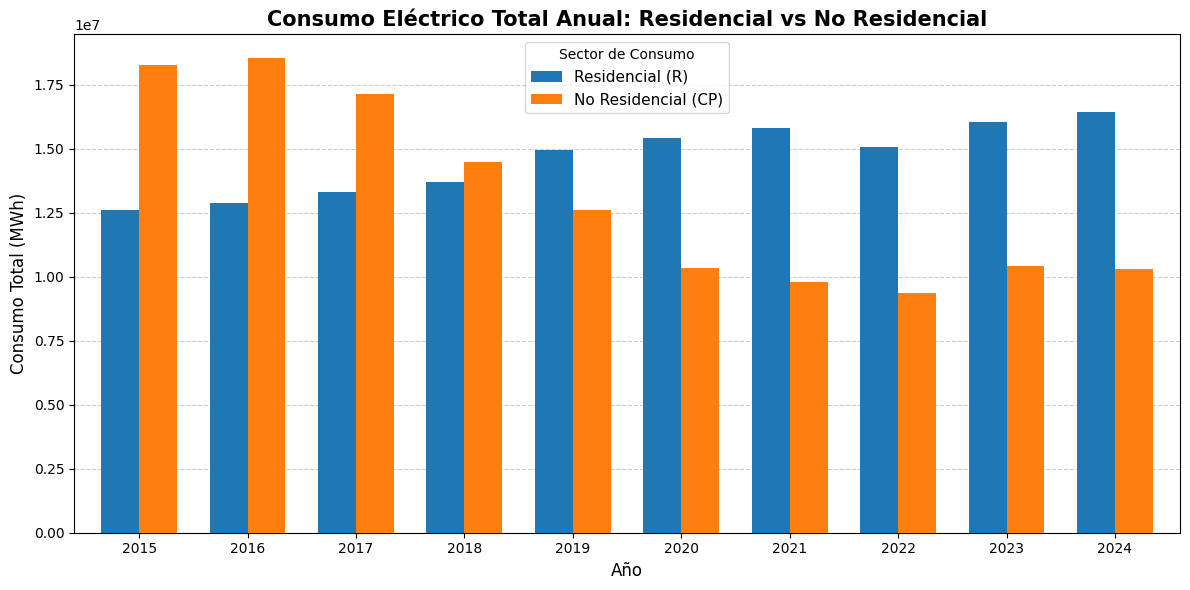

In [18]:
# 1. Extraer el año de la columna 'año_ms'
# Aseguramos que 'año_ms' sea datetime por si acaso
df_consumo_sectorial['año_ms'] = pd.to_datetime(df_consumo_sectorial['año_ms'])
df_consumo_sectorial['año'] = df_consumo_sectorial['año_ms'].dt.year

# 2. Agrupar por 'año' y sumar los consumos a nivel nacional
df_anual = df_consumo_sectorial.groupby('año')[['consumo_R_MWh', 'consumo_CP_MWh']].sum().reset_index()

# 3. Generar el gráfico de barras
# Seteamos el 'año' como índice para que Pandas lo use en el eje X automáticamente
df_plot = df_anual.set_index('año')

# Creamos la figura
ax = df_plot.plot(
    kind='bar', 
    figsize=(12, 6), 
    width=0.7, 
    color=['#1f77b4', '#ff7f0e'], # Azul para Residencial, Naranja para No Residencial
    zorder=10
)

# 4. Personalización del gráfico
plt.title('Consumo Eléctrico Total Anual: Residencial vs No Residencial', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Consumo Total (MWh)', fontsize=12)

# Modificar etiquetas de la leyenda para que sean más legibles
plt.legend(['Residencial (R)', 'No Residencial (CP)'], title='Sector de Consumo', fontsize=11)

# Mejorar la grilla y rotación de las fechas en el eje X
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Ajustar los márgenes para que no se corte nada
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [ ]:
correcciones_sector = {
    # Palabras clave en la razón social : Sector Real (RCPIT)
    "CENCOSUD": "C",
    "WALMART": "C",
    "FALABELLA": "C",
    "MALL": "C",
    "SUPERMERCADO": "C",
    "SODIMAC": "C",
    "HOSPITAL": "P", # Público / Servicios
    "CLINICA": "P",
    "METRO": "T",    # Transporte
    "EFE": "T", 
    "UNIVERSIDAD": "P", 
    "SALUD": "P", 
    "INMOBILIARIA": "C"
}

In [20]:
df_clientes_libres.columns

Index(['Anio', 'NroMes', 'Mes', 'RazonSocialSuministrador',
       'RazonSocialCliente', 'SectorEconomico', 'SubsectorEconomico',
       'TipodeCliente', 'Comuna', 'RetiroEnergiaMWh', 'region_cod', 'Region'],
      dtype='str')

In [21]:
df = df_clientes_libres.copy()

# 1. Transformación de Tipos de Datos y Fecha
df['Anio'] = pd.to_numeric(df['Anio'], errors='coerce')
df['NroMes'] = pd.to_numeric(df['NroMes'], errors='coerce')
df['RetiroEnergiaMWh'] = pd.to_numeric(df['RetiroEnergiaMWh'], errors='coerce')

# Limpiar nulos en fecha y crear columna datetime 'año_ms'
df = df.dropna(subset=['Anio', 'NroMes'])
df['año_ms'] = pd.to_datetime(
    df['Anio'].astype(int).astype(str) + '-' + 
    df['NroMes'].astype(int).astype(str).str.zfill(2) + '-01'
)

# 2. Estandarización de texto para búsqueda robusta
# Pasamos sectores a minúsculas y limpiamos espacios. La Razón Social a mayúsculas.
df['Sector_norm'] = df['SectorEconomico'].astype(str).str.lower().str.strip()
df['Subsector_norm'] = df['SubsectorEconomico'].astype(str).str.lower().str.strip()
df['Razon_norm'] = df['RazonSocialCliente'].astype(str).str.upper()

# 3. Clasificación Base inicial (mapeo general)
def mapeo_inicial(sector):
    if 'industrial' in sector or 'minero' in sector:
        return 'I'
    elif 'comercial' in sector:
        return 'C'
    elif 'público' in sector or 'publico' in sector or 'servicio' in sector:
        return 'P'
    elif 'transporte' in sector:
        return 'T'
    return 'Otros'

df['Sector_RCPIT'] = df['Sector_norm'].apply(mapeo_inicial)

# 4. APLICACIÓN DE REGLAS DE CORRECCIÓN (Sobrescribiendo la clasificación base)

# Regla A: Sector comercial + Subsector industrias varias -> Industrial
mask_a = (df['Sector_norm'] == 'comercial') & (df['Subsector_norm'] == 'industrias varias')
df.loc[mask_a, 'Sector_RCPIT'] = 'I'

# Regla B: Sector transporte + Subsector distinto a terrestre -> Comercial
mask_b = (df['Sector_norm'] == 'transporte') & (df['Subsector_norm'] != 'terrestre')
df.loc[mask_b, 'Sector_RCPIT'] = 'C'

# Regla C: Búsqueda de Palabras Clave en la Razón Social
diccionario_razon_social = {
    "CENCOSUD": "C", "WALMART": "C", "FALABELLA": "C", "MALL": "C",
    "SUPERMERCADO": "C", "SODIMAC": "C", "INMOBILIARIA": "C",
    "HOSPITAL": "P", "CLINICA": "P", "UNIVERSIDAD": "P", "SALUD": "P",
    "METRO": "T", "EFE": "T"
}

for palabra, sector_asignado in diccionario_razon_social.items():
    # Buscamos si la palabra clave está dentro de la Razón Social
    mask_c = df['Razon_norm'].str.contains(palabra, na=False)
    df.loc[mask_c, 'Sector_RCPIT'] = sector_asignado

# 5. Agrupación (Pivot Table) por Fecha, Región y Comuna
# Aquí se suman los consumos de distintas empresas que coinciden en comuna/mes y sector
df_agrupado = pd.pivot_table(
    df,
    values='RetiroEnergiaMWh',
    index=['año_ms', 'Region', 'Comuna'],
    columns='Sector_RCPIT',
    aggfunc='sum',
    fill_value=0
).reset_index()

# 6. Asignar nombres finales solicitados a las columnas
# Usamos .get() por si acaso alguna categoría no resultó de la data (ej: no hay 'T')
df_agrupado['consumo_I_MWh'] = df_agrupado.get('I', 0)
df_agrupado['consumo_C_MWh'] = df_agrupado.get('C', 0)
df_agrupado['consumo_P_MWh'] = df_agrupado.get('P', 0)
df_agrupado['consumo_T_MWh'] = df_agrupado.get('T', 0)

# 7. Seleccionar columnas y limpiar nombres de ejes
columnas_finales = [
    'año_ms', 'Region', 'Comuna', 
    'consumo_I_MWh', 'consumo_C_MWh', 'consumo_P_MWh', 'consumo_T_MWh'
]
df_consumo_libres = df_agrupado[columnas_finales].copy()
df_consumo_libres.columns.name = None

# Mostrar resultados
print(df_consumo_libres.head())

      año_ms       Region                Comuna  consumo_I_MWh  consumo_C_MWh  \
0 2000-01-01  ANTOFAGASTA           ANTOFAGASTA       214796.9            0.0   
1 2000-01-01  ANTOFAGASTA                CALAMA       240286.5            0.0   
2 2000-01-01  ANTOFAGASTA            MEJILLONES        16892.6            0.0   
3 2000-01-01  ANTOFAGASTA  SAN PEDRO DE ATACAMA         9280.2            0.0   
4 2000-01-01  ANTOFAGASTA          SIERRA GORDA        11293.6            0.0   

   consumo_P_MWh  consumo_T_MWh  
0            0.0            0.0  
1            0.0            0.0  
2            0.0            0.0  
3            0.0            0.0  
4            0.0            0.0  
